# 01 — Explore Data

Ecommerce KPI RAG Capstone — LLM Zoomcamp 2026

This notebook loads the raw dataset, merges the tables we need, and produces the summary
statistics that feed both the RAG document store (Notebook 02) and the README.

## 1. Load raw data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "../data"

customers = pd.read_csv(f"{DATA_DIR}/customers.csv")
products = pd.read_csv(f"{DATA_DIR}/products.csv")
transactions = pd.read_csv(f"{DATA_DIR}/transactions.csv", parse_dates=["timestamp"])
campaigns = pd.read_csv(f"{DATA_DIR}/campaigns.csv")

print("customers:   ", customers.shape)
print("products:    ", products.shape)
print("transactions:", transactions.shape)
print("campaigns:   ", campaigns.shape)

customers:    (100000, 7)
products:     (2000, 6)
transactions: (103127, 9)
campaigns:    (50, 7)


Note: `events.csv` (2,000,000 rows) is intentionally excluded from this pipeline — it's not
needed for KPI reporting and is too large to commit to Git (see the project README for the
Kaggle-download workaround if you need it for a different analysis).

## 2. Merge transactions with product and customer attributes

In [2]:
df = transactions.merge(products, on="product_id", how="left")
df = df.merge(customers, on="customer_id", how="left", suffixes=("", "_customer"))

print(df.shape)
df.head()

(103127, 20)


,transaction_id,timestamp,customer_id,product_id,quantity,discount_applied,gross_revenue,campaign_id,refund_flag,category,brand,base_price,launch_date,is_premium,signup_date,country,age,gender,loyalty_tier,acquisition_channel
0,1,2021-12-27 08:25:15,59540,1630.0,3,0.00,43.74,0,0,Grocery,Brand_76,14.58,2022-11-02,0.0,2021-11-26,IN,39,Female,Silver,Organic
1,2,2023-06-06 21:14:26,54871,1901.0,3,0.00,174.78,21,0,Home,Brand_20,58.26,2022-09-21,0.0,2021-06-24,IN,35,Female,Bronze,Paid Search
2,3,2023-08-31 05:29:54,51818,1884.0,1,0.00,40.61,37,0,Fashion,Brand_23,40.61,2021-04-24,0.0,2021-07-17,CA,49,Female,Platinum,Organic
3,4,2022-06-26 20:33:46,18164,1114.0,2,0.15,68.76,13,0,Sports,Brand_19,40.45,2021-05-26,0.0,2022-01-30,UK,27,Male,Bronze,Organic
4,5,2023-07-26 18:12:35,86915,408.0,1,0.00,14.64,4,0,Grocery,Brand_39,14.64,2022-01-08,0.0,2023-06-15,US,26,Male,Bronze,Email


## 3. Data quality checks

In [3]:
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

print("\nDuplicate transaction_ids:", df["transaction_id"].duplicated().sum())
print("Date range:", df["timestamp"].min(), "to", df["timestamp"].max())
print("Refund rate: {:.2%}".format(df["refund_flag"].mean()))

Missing values per column:
product_id       10449
gross_revenue    10449
category         10449
brand            10449
base_price       10449
launch_date      10449
is_premium       10449
dtype: int64

Duplicate transaction_ids: 0
Date range: 2021-01-01 00:12:50 to 2023-12-31 22:37:32
Refund rate: 2.94%


**Finding:** 10,449 transactions (~10.1% of the table) have a missing `product_id` and
`gross_revenue` — this is present in the raw `transactions.csv`, not introduced by the merge
(confirmed by checking the raw file directly; every `product_id` that *is* present matches a
real row in `products.csv`, so it isn't a join mismatch either). These rows are excluded from
revenue and category breakdowns below since there's no reliable way to recover the missing
values. Flagging this as a known data quality gap for the README rather than silently dropping
it — it's worth resolving at the source if this dataset is used again.

## 4. Summary statistics

In [4]:
total_revenue = df["gross_revenue"].sum()
total_orders = df["transaction_id"].nunique()
avg_order_value = df["gross_revenue"].mean()

print(f"Total revenue:      ${total_revenue:,.2f}")
print(f"Total orders:       {total_orders:,}")
print(f"Average order value: ${avg_order_value:,.2f}")
print(f"Unique customers who purchased: {df['customer_id'].nunique():,}")
print(f"Unique products sold:           {df['product_id'].nunique():,}")

Total revenue:      $8,373,966.36
Total orders:       103,127
Average order value: $90.36
Unique customers who purchased: 64,035
Unique products sold:           2,000


## 5. Revenue by category

In [5]:
category_revenue = (
    df.groupby("category")["gross_revenue"]
    .sum()
    .sort_values(ascending=False)
)
category_revenue

category
Electronics    3452007.19
Home           1996432.94
Fashion        1298075.77
Sports          965609.13
Beauty          369671.88
Grocery         292169.45
Name: gross_revenue, dtype: float64

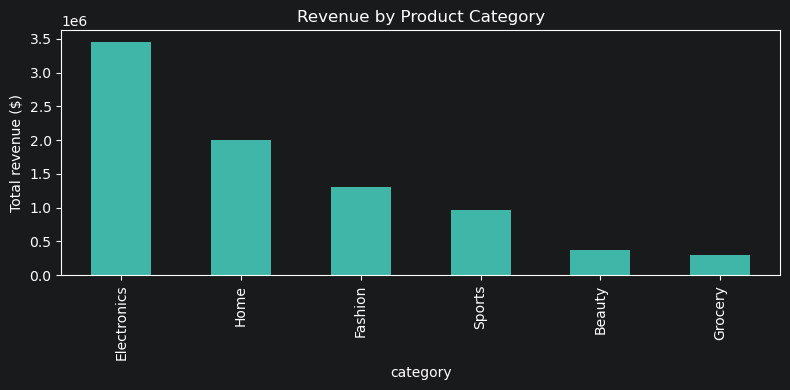

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
category_revenue.plot(kind="bar", ax=ax, color="#3FB6A8")
ax.set_ylabel("Total revenue ($)")
ax.set_title("Revenue by Product Category")
plt.tight_layout()
plt.savefig("../data/category_revenue.png", dpi=150)
plt.show()

## 6. Revenue by country and loyalty tier

In [7]:
country_revenue = df.groupby("country")["gross_revenue"].sum().sort_values(ascending=False)
loyalty_revenue = df.groupby("loyalty_tier")["gross_revenue"].sum().sort_values(ascending=False)

print("Revenue by country:")
print(country_revenue)
print("\nRevenue by loyalty tier:")
print(loyalty_revenue)

Revenue by country:
country
US    2950087.57
IN    1679708.93
UK     844255.29
BR     836797.43
CA     817855.39
DE     654466.43
AU     590795.32
Name: gross_revenue, dtype: float64

Revenue by loyalty tier:
loyalty_tier
Bronze      4477838.77
Silver      2302086.76
Gold        1275144.30
Platinum     318896.53
Name: gross_revenue, dtype: float64


## 7. Monthly revenue trend

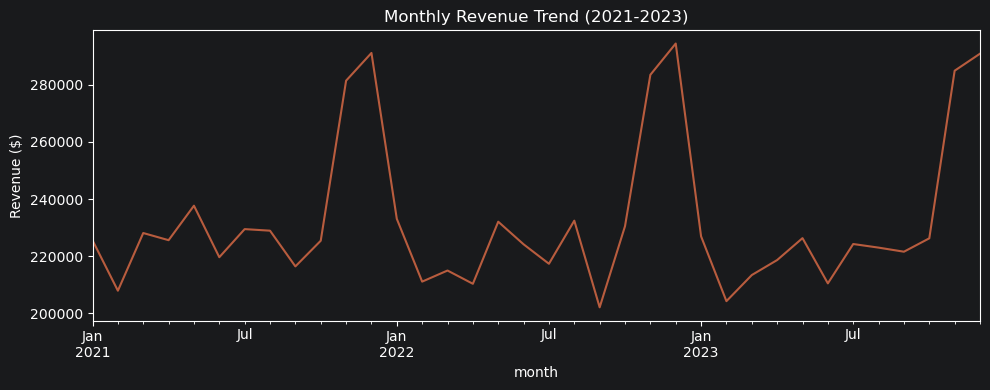

In [8]:
df["month"] = df["timestamp"].dt.to_period("M")
monthly_revenue = df.groupby("month")["gross_revenue"].sum()

fig, ax = plt.subplots(figsize=(10, 4))
monthly_revenue.plot(ax=ax, color="#B85C3E")
ax.set_ylabel("Revenue ($)")
ax.set_title("Monthly Revenue Trend (2021-2023)")
plt.tight_layout()
plt.savefig("../data/monthly_revenue.png", dpi=150)
plt.show()

## 8. Campaign performance

In [9]:
campaign_revenue = (
    df[df["campaign_id"] > 0]
    .merge(campaigns, on="campaign_id", how="left")
    .groupby("channel")["gross_revenue"]
    .sum()
    .sort_values(ascending=False)
)
campaign_revenue

channel
Affiliate      1608144.17
Paid Search    1533909.64
Email          1357550.66
Display        1211416.38
Social          972825.47
Name: gross_revenue, dtype: float64

## 9. Save the merged dataset for downstream notebooks

In [10]:
df.to_csv(f"{DATA_DIR}/merged_transactions.csv", index=False)
print("Saved merged_transactions.csv:", df.shape)

Saved merged_transactions.csv: (103127, 21)


## Summary

- **103,127 transactions** across **6 product categories** (Grocery, Fashion, Electronics, Sports, Beauty, Home)
- **100,000 customers** across **7 countries** (US, IN, UK, BR, CA, DE, AU) and 4 loyalty tiers
- **Total revenue: ~$8.37M** over Jan 2021 - Dec 2023 (avg order value ~$90.36)
- **Refund rate: ~2.9%**
- **Data quality issue found:** 10,449 transactions (~10.1%) are missing `product_id` and
  `gross_revenue` in the raw source data — excluded from revenue calculations, flagged in the README
- No duplicate transaction IDs
- Electronics is the top-revenue category (~$3.45M); Grocery is the lowest (~$292K)
- US is the top-revenue country (~$2.95M); Australia is the lowest (~$591K)

This merged, cleaned dataset (`merged_transactions.csv`) is what Notebook 02 uses to build
the RAG document store.